# Stage 1 — Audio + Framing Pipeline

DeepSC-S never touches raw speech samples with its CNN — it first reshapes the 1-D waveform into a 2-D matrix, because 2-D convolutions (borrowed from image models) are what the semantic encoder is built from.

**This notebook establishes:**
1. Load/resample audio to 8 kHz.
2. Frame a length-16384 window into a 128x128 matrix `m in F x L`.
3. Deframe back to a waveform, **bit-exact** (`atol=0`).
4. Visualize every intermediate: waveform, spectrogram, the framed matrix as an image.
5. Handle real files whose length isn't a clean multiple of 16384.

No neural net yet — this stage is pure signal-processing plumbing, but getting it exactly right (lossless) is what makes every later stage trustworthy: if reconstruction quality degrades, it's the *model's* fault, not a framing bug.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from deepscs.audio import SR, W, F, L, load_audio, frame, deframe, crop_or_pad, tile_frames, reassemble, sdr
from deepscs.data import toy_batch
from deepscs.viz import plot_waveform, plot_spectrogram, plot_framed_image

plt.rcParams["figure.figsize"] = (10, 3)
print(f"SR={SR}, W={W}, frame shape=({F},{L})")

SR=8000, W=16384, frame shape=(128,128)


## Toy data (zero download)

`deepscs.data.toy_batch` synthesizes 8 kHz "speech-like" clips: a chirp sweep (mimics pitch glide) + a few amplitude-modulated tones at formant-like frequencies (300/900/2500 Hz) + short noise bursts (mimics consonant transients). It's not real speech, but it has the same broad structure — tonal + noisy + non-stationary — so every stage 1-3 concept is visible without a multi-GB dataset download.

(16384,) float32 peak amplitude: 0.9


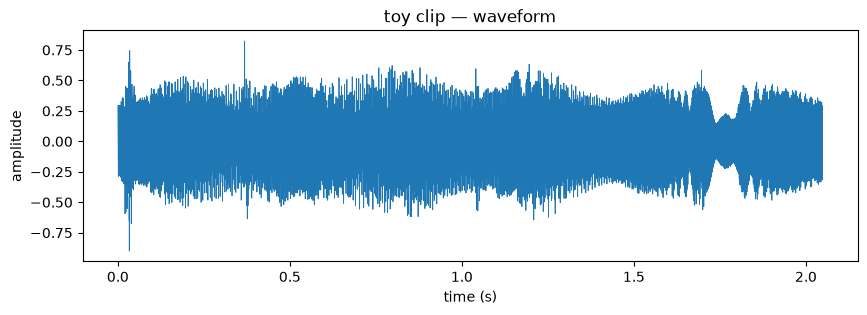

In [2]:
clip = toy_batch(1, length=W, seed=0)[0]
print(clip.shape, clip.dtype, "peak amplitude:", np.abs(clip).max())

fig, ax = plt.subplots()
plot_waveform(ax, clip, title="toy clip — waveform")
plt.show()

## Spectrogram

The mel spectrogram shows what the framed image (below) does *not*: time-frequency structure. Framing is a **reshape**, not an STFT — it throws away the notion of "frequency axis" entirely and just chops the raw sample stream into rows. Compare the two representations.

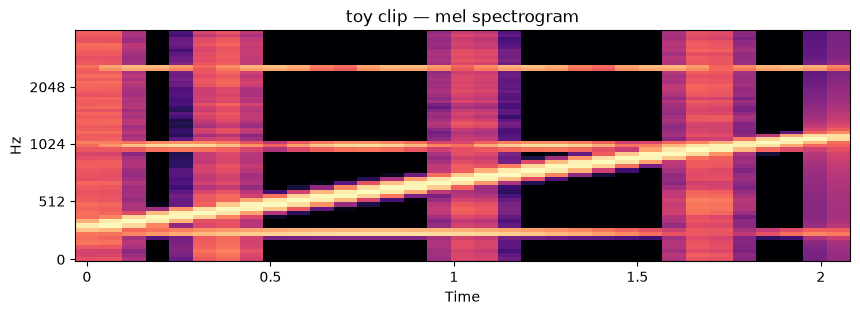

In [3]:
fig, ax = plt.subplots()
plot_spectrogram(ax, clip, title="toy clip — mel spectrogram")
plt.show()

## Framing: 1-D signal to 2-D "image"

`frame(x)` reshapes the flat 16384-sample vector into a `128x128` matrix, **row-major**: samples `0..127` become row 0, `128..255` become row 1, etc. No windowing, no overlap, no frequency transform — it's the numpy-equivalent of `x.reshape(128, 128)`.

Why bother? Because the semantic encoder (stage 2) is a stack of 2-D convolutions (SE-ResNet blocks) — the same architecture family used for images. Reshaping the audio into a matrix lets a 2-D CNN slide filters across chunks of consecutive samples in both "row" and "column" directions, picking up local structure at multiple scales, exactly like it would on image pixels.

framed shape: (128, 128)


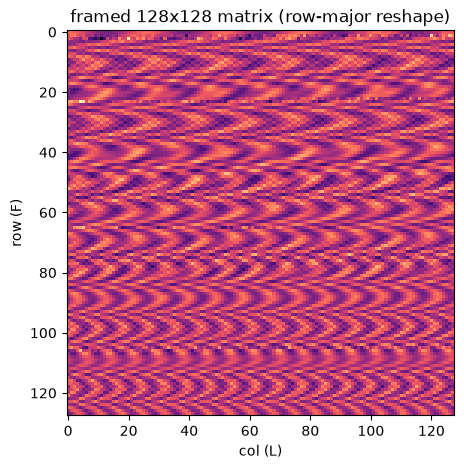

In [4]:
m = frame(clip)
print("framed shape:", m.shape)

fig, ax = plt.subplots(figsize=(5, 5))
plot_framed_image(ax, m, title="framed 128x128 matrix (row-major reshape)")
plt.show()

**Experiment — row-major vs column-major.** Row-major reshape keeps each row as 128 *consecutive* samples (a short, coherent snippet of waveform) — so nearby rows look highly correlated, and you can often see the amplitude envelope as horizontal banding. Column-major (`order='F'`) instead scatters temporally-adjacent samples across different rows, striping the matrix — it looks close to structured noise because the CNN's local receptive field no longer aligns with a contiguous time window.

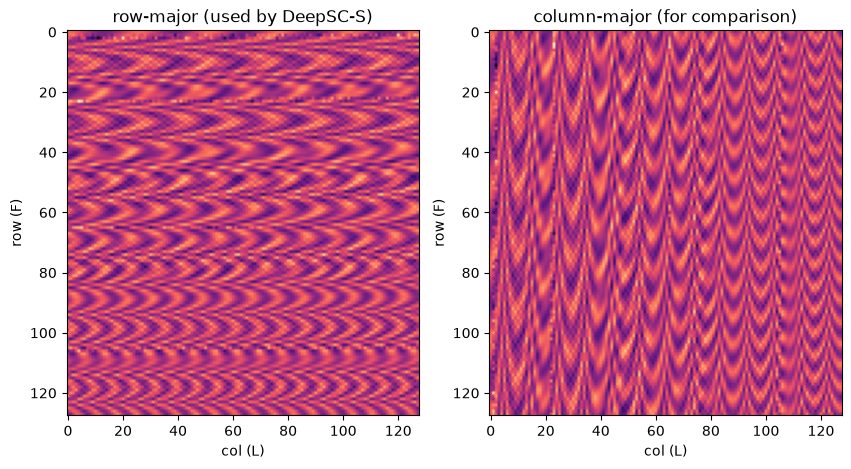

In [5]:
m_col = clip.reshape(F, L, order="F")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_framed_image(axes[0], m, title="row-major (used by DeepSC-S)")
plot_framed_image(axes[1], m_col, title="column-major (for comparison)")
plt.show()

## Round trip — must be lossless

`deframe` is `frame`'s exact inverse: flatten the matrix back to 1-D. No information should be lost — this is checked with `atol=0` (bit-exact), not an approximate tolerance, because framing is just a reshape and reshapes are lossless by construction. If this assertion ever fails, something is wrong with the *plumbing*, not the model.

In [6]:
recon = deframe(m)
assert np.array_equal(clip, recon), "round trip is not bit-exact!"
print("frame -> deframe round trip: EXACT MATCH (atol=0)")
print("SDR (should be inf, identical signals):", sdr(clip, recon))

frame -> deframe round trip: EXACT MATCH (atol=0)
SDR (should be inf, identical signals): inf


In [7]:
print("toy clip:")
display(Audio(clip, rate=SR))
print("round-tripped (should sound identical):")
display(Audio(recon, rate=SR))

toy clip:


round-tripped (should sound identical):


## Length handling for real files

Real recordings are rarely an exact multiple of `W=16384` samples. Two policies (see `deepscs/audio.py`):

- **Train:** `crop_or_pad` — take a random `W`-length crop (data augmentation via random offset); zero-pad if the whole clip is shorter than `W`.
- **Eval:** `tile_frames` / `reassemble` — split into non-overlapping `W`-length tiles, zero-padding only the final tile, then concatenate and trim back to the original length. This guarantees every sample gets reconstructed exactly once, with no overlap-add artifacts.

In [8]:
long_clip = toy_batch(1, length=40000, seed=1)[0]
tiles = tile_frames(long_clip, W)
print(f"length {len(long_clip)} -> {len(tiles)} tiles of {W} (last one zero-padded)")

restored = reassemble(tiles, len(long_clip))
assert np.array_equal(long_clip, restored), "tile/reassemble is not bit-exact!"
print("tile_frames -> reassemble round trip: EXACT MATCH (atol=0)")

short_clip = toy_batch(1, length=5000, seed=2)[0]
cropped = crop_or_pad(short_clip, W)
print(f"short clip {len(short_clip)} samples -> zero-padded to {cropped.shape[0]}")
assert np.array_equal(cropped[: len(short_clip)], short_clip)

length 40000 -> 3 tiles of 16384 (last one zero-padded)
tile_frames -> reassemble round trip: EXACT MATCH (atol=0)
short clip 5000 samples -> zero-padded to 16384


## Verify (success criterion #1)

`assert deframe(frame(s)) == s` bit-exact, on toy data *and* on a batch, confirms the framing pipeline introduces zero distortion of its own.

In [9]:
batch = toy_batch(8, seed=42)
for i, s in enumerate(batch):
    r = deframe(frame(s))
    assert np.array_equal(s, r), f"clip {i} failed round trip"
print(f"all {len(batch)} clips: bit-exact frame/deframe round trip. Stage 1 verified.")

all 8 clips: bit-exact frame/deframe round trip. Stage 1 verified.
